# Lab 5.1: Convolutions

In this lab you will see how the 2D cross-correlation filter can act as a simple pattern recognizer or object detector.

In [34]:
!wget -q -nc -O cat.jpg "https://www.dropbox.com/scl/fi/vc3j08yctlosvpr57v2ot/cat.jpg?rlkey=nbgc9klg8wlgkfewk08ln72xf&dl=1"

In [35]:
from imageio.v3 import imread, imwrite
from skimage.transform import rescale
from scipy.ndimage import convolve, correlate
from skimage.color import rgb2gray
from matplotlib import pyplot as plt
import numpy as np

### Exercises

1. Load the `cat.jpg` image, rescale it by 50%, and convert to grayscale as done in Notebook 5.1.

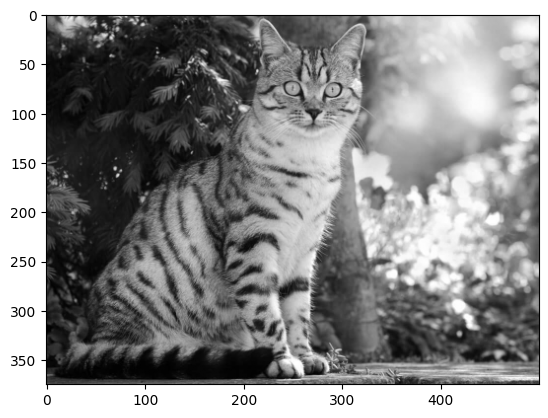

In [36]:
# YOUR CODE GOES HERE
img = imread('cat.jpg')
img = rescale(img, 0.5, anti_aliasing=True, channel_axis=-1)
img = rgb2gray(img)
plt.imshow(img, cmap='gray')

2. These coordinates specify a box around the cat's face:

- Top, Left: (0,205)
- Bottom, Right: (128,325)

Crop the `gray` image to this box and show the result.  It should show just the cat's face.

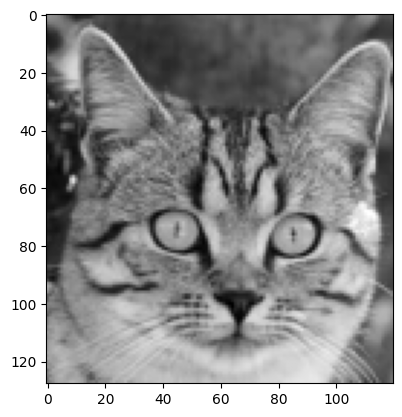

In [37]:
# YOUR CODE GOES HERE
gray = img
cropped = gray[0:128, 205:325]
plt.imshow(cropped, cmap='gray')

3. To turn the cat face into a filter, subtract the mean from the cropped image.

Print out the mean of the filter to verify that it is zero.

In [38]:
# YOUR CODE GOES HERE
filter = cropped - np.mean(cropped)
print(np.mean(filter))

7.401486830834377e-18


4. Apply the cat face filter to the original `gray` image using cross-correlation and show the result.

You should see a bright spot at the location of middle of the cat's face.  Why?

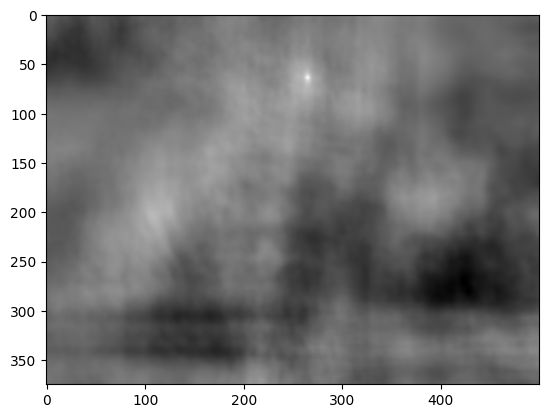

In [39]:
# YOUR CODE GOES HERE
result = correlate(gray, filter)
plt.imshow(result, cmap='gray')

Because cross-correlation uses a dot product, and the similarity between the cat's face filter that we chose and the original image at the cat's original face location are exactly the same, we get a very bright spot, symbolizing the similarity between these being extremely high.

5. Now let's crop one of the eyes and see how that well that works as an eye detector.

The left eye's coordinates:
- Top, Left: 68, 241
- Bottom, Right: 82, 256

Crop out the left eye, convert to a filter, and show the result of cross-correlation.

Does it detect both eyes well, or just the left eye?

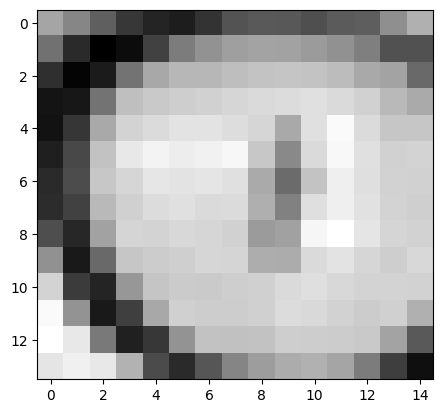

In [44]:
cropped = gray[68:82, 241:256]
plt.imshow(cropped, cmap='gray')

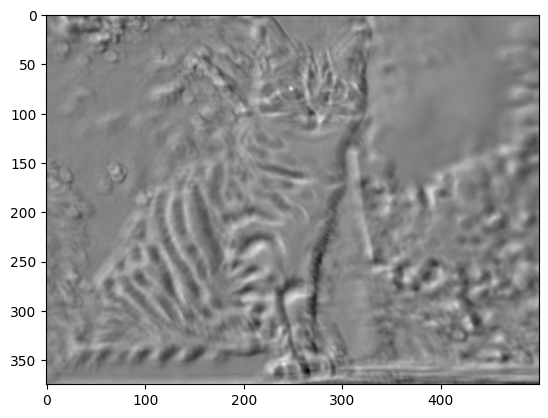

In [45]:
# YOUR CODE GOES HERE
filter = cropped - np.mean(cropped)
result = correlate(gray, filter)
plt.imshow(result, cmap='gray')

It only detects the left eye well.

6. To improve the result of the eye detector, we can crop both eyes and average them together before creating the filter.

Here are the right eye coordinates:
- Top, Left: 70, 282
- Bottom, Right: 84, 300

Crop out the right eye, compute the average of the left eye and right eye crops, and then create the filter from that and show the result.

Does the averaged eye filter detect both eyes more effectively than the left eye filter?  Why?

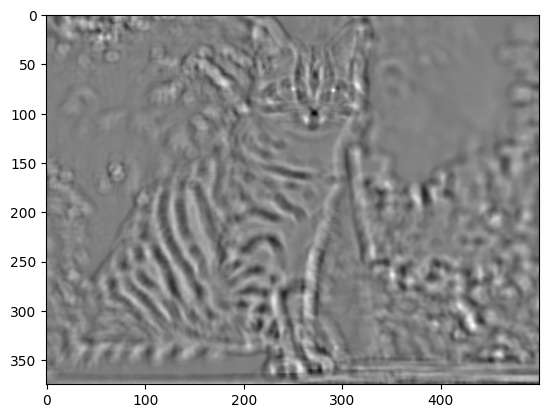

In [47]:
# YOUR CODE GOES HERE
cropped_left = gray[68:82, 241:259]
cropped_right = gray[70:84, 282:300]
cropped = (cropped_left + cropped_right) / 2
filter = cropped - np.mean(cropped)
result = correlate(gray, filter)
plt.imshow(result, cmap='gray')

It detects both eyes well now. I assume due to the fact that now both "pixel shifts" that are taken account for with the average, the similar eye pattern is now picked up for both eyes and not strictly just for the left eye now.